# Assemble and Assess the PCO2A Data

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import PyCO2SYS as pyco2
import sys
import warnings
import xarray as xr
import zarr

from itertools import cycle

from ooi_data_explorations.common import get_annotations, load_gc_thredds
from ooi_data_explorations.qartod.discrete_samples import distance_to_cast
from ooi_data_explorations.combine_data import combine_datasets
from ooi_data_explorations.uncabled.process_pco2a import pco2a_datalogger
from pyseas.data.co2_functions import co2_co2flux

# load local utilities
sys.path.append('../')
from utils import apply_qc_results, calculate_alkalinity, load_discrete, load_ndbc, metadata_reset, robust_regression
from pco2a_metadata import PCO2A, ENCODINGS

# set display options for the panda notebooks and filter out some warnings
pd.set_option('display.max_columns', None)  # use shift-mouse wheel to scroll horizontally
#pd.set_option('display.max_rows', None)

# filter out some warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

## Set up Local Data Directories

The code in this notebook will generate data and save it to the user's local computer. This allows for the reuse of
the data (saving time). The root path set up and created below, should be updated based on the user's own system and
preferences.

In [2]:
# Create root path in user's home directory
root_path = os.path.join(os.path.expanduser('~'), 'ooidata', 'carbonate')

# Create the directories if they don't exist
os.makedirs(root_path, exist_ok=True)

# test to see if we are running in a JupyterHub environment (some of this processing takes some horsepower)
IS_JUPYTERHUB = (
    'JUPYTERHUB_API_TOKEN' in os.environ or
    'JUPYTERHUB_USER' in os.environ or
    'JUPYTERHUB_BASE_URL' in os.environ
)

if not IS_JUPYTERHUB:
    print(f'Note, running some of the code below outside of a JupyterHub environment may be slow. Consider loading this notebook into a JupyterHub environment.')

## Load and Prepare Co-Located Data

We'll use data from the co-located NDBC moorings, the [SOCAT v2025 Coastal Data](https://socat.info/), and the discrete sample data collected during maintenace cruises in assessing the overall quality of the assembled PCO2A data records.

### Load the NDBC Buoy Data for Oregon (Station 46050, Stonewall Bank) and Washington (Station 46041, Cape Elizabeth)

In [3]:
external_path = os.path.join(root_path, 'external')  # external data sources used
os.makedirs(external_path, exist_ok=True)

#ndbc_46050 = load_ndbc('46050')  # Stonewall Bank, used for the Oregon moorings
#ndbc_46050.to_netcdf(os.path.join(external_path, 'NDBC_46050.nc'), mode='w', format='NETCDF4', engine='h5netcdf')
ndbc_46050 = xr.load_dataset(os.path.join(external_path, 'NDBC_46050.nc'), engine='h5netcdf')
#ndbc_46041 = load_ndbc('46041')  # Cape Elizabeth, used for the Washington moorings
#ndbc_46041.to_netcdf(os.path.join(external_path, 'NDBC_46041.nc'), mode='w', format='NETCDF4', engine='h5netcdf')
ndbc_46041 = xr.load_dataset(os.path.join(external_path, 'NDBC_46041.nc'), engine='h5netcdf')

# there are a couple periods of bad data in the NDBC records
m = (ndbc_46050['time'] >= pd.Timestamp('2015-04-01')) & (ndbc_46050['time'] <= pd.Timestamp('2015-04-21')) 
ndbc_46050 = ndbc_46050.where(~m, drop=True)
m = (ndbc_46041['time'] >= pd.Timestamp('2017-08-21')) & (ndbc_46041['time'] <= pd.Timestamp('2017-09-24')) 
ndbc_46041 = ndbc_46041.where(~m, drop=True)

# create a 10 m normalized wind product
u10 = (ndbc_46050['wspu']**2 + ndbc_46050['wspv']**2)**0.5 * (10.0 / 4.0)**0.2  # 10 m normalized wind speed
ndbc_46050['normalized_10m_wind'] = u10
u10 = (ndbc_46041['wspu']**2 + ndbc_46041['wspv']**2)**0.5 * (10.0 / 4.0)**0.2  # 10 m normalized wind speed
ndbc_46041['normalized_10m_wind'] = u10

### Load the [SOCAT](https://socat.info/) Data

For this analysis we need the SOCAT v2025 Coastal data. That data file is quite large (3.6 GB) and trying to load it in can take a while. I used the code below after downloading the V2025 coastal data from the [SOCAT web site](https://socat.info/), and then pared it down to a data set specific to the Endurance Array region. The pared down data set was then saved as a local csv file, which can be reloaded much quicker and easier than having to reload the whole thing from scratch.

``` python
# explicitly set the column data types and load the SOCAT v2025 North Pacific data
col_types = {'Expocode': str, 'version': str, 'Source_DOI': str, 'QC_Flag': str, 'yr': int, 'mon': int, 'day': int,
       'hh': int, 'mm': int, 'ss': int, 'longitude [dec.deg.E]': float, 'latitude [dec.deg.N]': float,
       'sample_depth [m]': float, 'sal': float, 'SST [deg.C]': float, 'Tequ [deg.C]': float, 'PPPP [hPa]': float,
       'Pequ [hPa]': float, 'WOA_SSS': float, 'NCEP_SLP [hPa]': float, 'ETOPO2_depth [m]': float,
       'dist_to_land [km]': float, 'GVCO2 [umol/mol]': float, 'xCO2water_equ_dry [umol/mol]': float,
       'xCO2water_SST_dry [umol/mol]': float, 'pCO2water_equ_wet [uatm]': float,
       'pCO2water_SST_wet [uatm]': float, 'fCO2water_equ_wet [uatm]': float,
       'fCO2water_SST_wet [uatm]': float, 'fCO2rec [uatm]': float, 'fCO2rec_src': int,
       'fCO2rec_flag': int}

# the coastal file is BIG!
socat = []
for chunk in pd.read_csv('SOCATv2025_Coastal.tsv', sep='\t', header=0, dtype=col_types, chunksize=1000000):
    # limit the data to our time range of interest
    chunk = chunk[(chunk['yr'] >= 2015) & (chunk['mon'] >= 4)]
    if chunk.empty:  # no data of possible interest in this chunk
        continue 
    
    # play a little game with the longitude and latitiude column names so we can use the distance_to_cast function later on
    chunk = chunk.rename(columns={'longitude [dec.deg.E]': 'Start Longitude [degrees]', 'latitude [dec.deg.N]': 'Start Latitude [degrees]'})

    # limit the north/south extent of the data
    chunk = chunk[(chunk['Start Latitude [degrees]'] >= 43) & (chunk['Start Latitude [degrees]'] <= 48)]
    if chunk.empty:  # no data of possible interest in this chunk
        continue 

    # limit the east/west extent of the data
    m = chunk['Start Longitude [degrees]'] > 180.0
    chunk['Start Longitude [degrees]'][m] = chunk['Start Longitude [degrees]'][m] - 360.0  # convert from 0:360 to -180:180 degrees
    chunk = chunk[(chunk['Start Longitude [degrees]'] >= -127) & (chunk['Start Longitude [degrees]'] <= -122)]  # limit to EA mooring locations
    if chunk.empty:  # no data of possible interest in this chunk
        continue 

    # if we still have data left, append it to the list
    socat.append(chunk)

# assemble the chunks into a final dataframe
socat = pd.concat(socat, ignore_index=True)

# calculate a datetime value and get rid of the columns we don't need going forward
socat['sample_date'] = pd.to_datetime(dict(year=socat['yr'], month=socat['mon'], day=socat['day'], hour=socat['hh'], minute=socat['mm'], second=socat['ss']), utc=True)
socat = socat.drop(['Expocode', 'version', 'Source_DOI', 'yr', 'mon', 'day', 'hh', 'mm','ss'], axis=1)

# save the resulting pared down file for later use
socat.to_csv('socat_v2025_endurance.csv', index=False)
```

In [4]:
# load the pared down data set
socat = pd.read_csv(os.path.join(external_path, 'socat_v2025_endurance.csv'))

# convert the fCO2 values to pCO2
co2 = pyco2.sys(par1=socat['fCO2rec [uatm]'], par1_type=5, salinity=socat['sal'], pressure=0, temperature=socat['SST [deg.C]'])
socat['pCO2 SSW [uatm]'] = co2['pCO2']

# convert the 
co2 = pyco2.sys(par1=socat['GVCO2 [umol/mol]'], par1_type=9)
socat['pCO2 ATM [uatm]'] = co2['pCO2']
socat

,QC_Flag,Start Longitude [degrees],Start Latitude [degrees],sample_depth [m],sal,SST [deg.C],Tequ [deg.C],PPPP [hPa],Pequ [hPa],WOA_SSS,NCEP_SLP [hPa],ETOPO2_depth [m],dist_to_land [km],GVCO2 [umol/mol],xCO2water_equ_dry [umol/mol],xCO2water_SST_dry [umol/mol],pCO2water_equ_wet [uatm],pCO2water_SST_wet [uatm],fCO2water_equ_wet [uatm],fCO2water_SST_wet [uatm],fCO2rec [uatm],fCO2rec_src,fCO2rec_flag,sample_date,pCO2 SSW [uatm],pCO2 ATM [uatm]
0,C,-123.0080,47.3750,NaN,23.081,12.543,NaN,NaN,1028.70,35.000,1029.4,-58.0,0.0,405.765,NaN,332.8,NaN,333.1,NaN,331.90,331.904,2,2,2015-04-02 21:17:00+00:00,333.145258,393.326152
1,C,-123.0080,47.3750,NaN,26.848,11.512,NaN,NaN,1008.00,35.000,1005.6,-58.0,0.0,405.765,NaN,323.2,NaN,317.2,NaN,316.00,316.069,2,2,2015-04-05 18:17:00+00:00,317.266841,393.326152
2,C,-123.0080,47.3750,NaN,27.423,11.458,NaN,NaN,1009.90,35.000,1011.0,-58.0,0.0,405.974,NaN,273.5,NaN,269.0,NaN,268.00,267.988,2,2,2015-04-06 18:17:00+00:00,269.004332,393.528745
3,C,-123.0080,47.3750,NaN,24.094,12.280,NaN,NaN,1011.00,35.000,1011.1,-58.0,0.0,405.974,NaN,262.2,NaN,258.0,NaN,257.00,257.010,2,2,2015-04-07 18:17:00+00:00,257.974425,393.528745
4,C,-123.0080,47.3750,NaN,26.540,11.758,NaN,NaN,1018.50,35.000,1019.5,-58.0,0.0,405.974,NaN,244.2,NaN,242.2,NaN,241.30,241.273,2,2,2015-04-08 18:17:00+00:00,242.184481,393.528745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121664,A,-126.9743,45.3906,NaN,32.117,15.841,16.18,1007.4,1007.66,32.075,1008.6,2850.0,245.0,421.016,374.553,NaN,NaN,NaN,NaN,359.33,359.331,1,2,2023-10-14 03:21:40+00:00,360.619441,408.109628
121665,A,-126.9805,45.3802,NaN,32.134,15.850,16.19,1007.4,1007.76,32.075,1008.6,2851.0,246.0,421.016,375.084,NaN,NaN,NaN,NaN,359.85,359.848,1,2,2023-10-14 03:24:13+00:00,361.138148,408.109628
121666,A,-126.9866,45.3698,NaN,31.873,15.861,16.20,1007.5,1007.76,32.075,1008.6,2860.0,246.0,421.017,376.615,NaN,NaN,NaN,NaN,361.33,361.327,1,2,2023-10-14 03:26:47+00:00,362.622270,408.110598
121667,A,-126.9926,45.3596,NaN,32.138,15.862,16.20,1007.5,1007.56,32.075,1008.6,2868.0,247.0,421.017,376.405,NaN,NaN,NaN,NaN,361.08,361.077,1,2,2023-10-14 03:29:20+00:00,362.371357,408.110598


In [5]:
def prep_socat(ds, socat, dist=2.5):
    """
    Find SOCAT samples co-located with mooring measurements in space and
    water mass.

    Uses distance between mooring and SOCAT sample locations, along with
    temperature differences, to identify samples that are spatially proximate
    and from the same water mass. Aligns mooring measurements within a
    45-minute time window and filters based on temperature agreement.

    Parameters
    ----------
    ds : xarray.Dataset
        Mooring dataset containing time series of sea surface measurements
        including salinity, temperature, and pCO2. Must have
        'geospatial_lat_min' and 'geospatial_lon_min' attributes.
    socat : pandas.DataFrame
        SOCAT data with sample locations, dates, and SST measurements. Must
        contain 'sample_date' and 'SST [deg.C]' columns.
    dist : float, optional
        Maximum distance threshold in kilometers (or appropriate units) for
        considering samples as co-located with the mooring. Default is 2.5.

    Returns
    -------
    pandas.DataFrame
        Filtered SOCAT samples with added mooring measurements
        (sea_surface_salinity, sea_surface_temperature, pco2_atm, pco2_ssw).
        Samples are filtered to within `dist` of the mooring, within 45
        minutes temporally, and with SOCAT-mooring temperature difference
        ≤0.50°C.

    """    
    # find the SOCAT data close to the mooring
    distance = distance_to_cast(socat, ds.attrs['geospatial_lat_min'], ds.attrs['geospatial_lon_min'])
    samples = socat[distance <= dist].copy()
    
    # set up the merged sample variables    
    samples['sea_surface_salinity'] = np.nan
    samples['sea_surface_temperature'] = np.nan
    samples['pco2_atm'] = np.nan
    samples['pco2_ssw'] = np.nan
    
    # vectorized alignment of mooring data with SOCAT samples
    ds_time_float = ds['time'].astype(float).values
    sample_times = pd.to_datetime(samples['sample_date']).values.astype(float)
    
    # convert to minutes
    dt_matrix = (ds_time_float[:, np.newaxis] - sample_times[np.newaxis, :]) / 1e9 / 60
    
    # find indices where time difference is within 45 minutes
    mask = np.abs(dt_matrix) <= 45
    
    # calculate medians for each sample
    for col, ds_var in [('sea_surface_salinity', 'sea_surface_salinity'),
                        ('sea_surface_temperature', 'sea_surface_temperature'),
                        ('pco2_atm', 'partial_pressure_co2_atm'),
                        ('pco2_ssw', 'partial_pressure_co2_ssw')]:
        ds_values = ds[ds_var].values
        medians = np.array([np.nanmedian(ds_values[mask[:, j]]) if mask[:, j].any() 
                           else np.nan for j in range(len(sample_times))])
        samples[col] = medians
    
    # remove records where the difference between SOCAT and the mooring temperature is >0.50 deg C
    degc_socat = samples['SST [deg.C]']
    degc_mooring = samples['sea_surface_temperature']
    samples = samples[(degc_socat - degc_mooring).abs() <= 0.50]
    
    # For the surface samples, remove erroneous DIC samples
    samples = samples[samples['pco2_ssw'] < 800]

    return samples

### Load the Discrete Sample Data for Endurance

In [6]:
depth = 1.25  # Buoy subsurface sensors, depth in meters
depth_limit = 4.0  # window to use to find applicable discrete samples (depth +- depth_limit)
sample_dist = [2.5, 5.0, 2.5, 5.0]  # distance in kilometers from the mooring to find applicable discrete samples
discrete = load_discrete(depth, depth_limit)
discrete = discrete[(discrete['Start Time [UTC]'] >= pd.to_datetime('2015-04-01T00:00:00Z'))]  # Endurance 3 to the present (PCO2A wasn't deployed prior)

In [7]:
def prep_samples(ds, discrete, dist=2.5):
    """
    Find discrete samples co-located with mooring measurements in space and
    water mass.

    Uses distance between mooring and discrete sample collection locations,
    along with temperature differences between the mooring and ship CTD, to
    identify samples that are spatially proximate and from the same water
    mass. Aligns mooring measurements within a 60-minute time window and 
    filters based on temperature agreement.

    Parameters
    ----------
    ds : xarray.Dataset
        Mooring dataset containing time series of sea surface measurements
        including salinity, temperature, pCO2, and alkalinity.
    discrete : pandas.DataFrame
        Discrete sample data with CTD measurements and bottle closure times.
        Must contain 'CTD Bottle Closure Time [UTC]', 'CTD Temperature 1
        [deg C]', 'CTD Temperature 2 [deg C]', and 'Calculated Alkalinity
        [umol/kg]' columns.
    dist : float, optional
        Maximum distance threshold in kilometers (or appropriate units) for
        considering samples as co-located with the mooring. Default is 2.5.

    Returns
    -------
    pandas.DataFrame
        Filtered discrete samples with added mooring measurements
        (sea_surface_salinity, sea_surface_temperature, pco2_atm, pco2_ssw,
        alkalinity). Samples are filtered to within `dist` of the mooring,
        within 45 minutes temporally, with mooring-CTD temperature difference
        ≤0.50°C, and unreasonable alkalinity values (>2300 umol/kg) set to
        NaN.

    """    
    # find discrete sample data close to the mooring
    distance = distance_to_cast(discrete, ds['latitude'].values, ds['longitude'].values)
    samples = discrete[distance <= dist].copy()
    
    # create placeholders to add the mooring data to the discrete samples
    samples['sea_surface_salinity'] = np.nan
    samples['sea_surface_temperature'] = np.nan
    samples['pco2_atm'] = np.nan
    samples['pco2_ssw'] = np.nan
    samples['alkalinity'] = np.nan
    
    # vectorized alignment of mooring data with discrete samples
    ds_time_float = ds['time'].astype(float).values
    sample_times = samples['CTD Bottle Closure Time [UTC]'].values.astype(float)
    
    # convert to minutes
    dt_matrix = (ds_time_float[:, np.newaxis] - sample_times[np.newaxis, :]) / 1e9 / 60
    
    # find indices where time difference is within 45 minutes
    mask = np.abs(dt_matrix) <= 45
    
    # calculate medians for each sample
    for col, ds_var in [('sea_surface_salinity', 'sea_surface_salinity'),
                        ('sea_surface_temperature', 'sea_surface_temperature'),
                        ('pco2_atm', 'partial_pressure_co2_atm'),
                        ('pco2_ssw', 'partial_pressure_co2_ssw'),
                        ('alkalinity', 'alkalinity')]:
        ds_values = ds[ds_var].values
        medians = np.array([np.nanmedian(ds_values[mask[:, j]]) if mask[:, j].any() 
                           else np.nan for j in range(len(sample_times))])
        samples[col] = medians
    
    # remove records where the difference between mooring and CTD water temperature
    # is greater than 0.50
    ctd = samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1)
    mooring = samples['sea_surface_temperature']
    samples = samples[(ctd - mooring).abs() <= 0.50]
    
    # For the surface samples, remove erroneous DIC samples
    samples = samples[samples['Calculated Alkalinity [umol/kg]'] < 2300]
    samples = samples[samples['Discrete pCO2 [uatm]'] < 800]
    samples = samples[samples['pco2_ssw'] < 800]
    
    return samples

## Processing Code for the PCO2A Data

In [8]:
# create a global variable with the drift corrections to use for the different moorings
CORRECTIONS = pd.read_csv('pco2a_drift_corrections.csv')
CORRECTIONS = CORRECTIONS.replace({np.nan: None})
CORRECTIONS

,mooring,deployment,start_date,end_date,correction
0,CE02SHSM,9,None,2019-08-15T20:30:00,"[13.0, 0.457]"
1,CE04OSSM,6,None,None,"[0.0, -0.392]"
2,CE04OSSM,8,None,2019-08-15T14:30:00,"[0.0, 0.629]"
3,CE07SHSM,1,None,None,"[0.0, 0.27]"
4,CE07SHSM,9,None,2019-08-15T18:30:00,"[0.0, 0.69]"
5,CE09OSSM,8,None,None,"[0.0, -0.06]"
6,CE09OSSM,9,None,2019-08-15T14:30:00,"[0.0, 0.589]"
7,CE09OSSM,10,None,None,"[0, 0.079]"
8,CE09OSSM,14,None,None,"[0.0, 0.054]"


In [9]:
def correction(ds, start, stop, scaling_factors):
    """
    Apply time-dependent corrections to pCO2 measurements affected by faulty firmware.

    For select deployments where faulty firmware caused the instrument to retain
    the original blank measurement instead of recording new blanks every 12 hours,
    this function applies scalar or linear time-dependent corrections to compensate
    for the gradual, linear decrease in calculated pCO2 values.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing 'partial_pressure_co2_atm' and 'partial_pressure_co2_ssw'
        variables to be corrected.
    start : str, pandas.Timestamp, or None
        Start time for the correction period (inclusive). If None, uses the minimum
        time value in the dataset.
    stop : str, pandas.Timestamp, or None
        End time for the correction period (inclusive). If None, uses the maximum
        time value in the dataset.
    scaling_factors : str
        String representation of a list containing correction factors:
        - Single value: Applies a constant offset to all measurements in the period.
        - Two values: Applies a linear correction (intercept + slope * elapsed_days).

    Returns
    -------
    xarray.Dataset
        Dataset with corrections applied to 'partial_pressure_co2_atm' and
        'partial_pressure_co2_ssw' within the specified time range.

    Raises
    ------
    ValueError
        If scaling_factors contains more than 2 terms.

    Notes
    -----
    The function uses `eval()` with restricted builtins to safely parse the
    scaling_factors string. For linear corrections, elapsed time is calculated
    in days from the start date.

    Examples
    --------
    >>> # Apply constant offset correction
    >>> ds_corrected = correction(ds, '2020-01-01', '2020-12-31', '[5.0]')

    >>> # Apply linear time-dependent correction
    >>> ds_corrected = correction(ds, '2020-01-01', '2020-12-31', '[10.0, -0.05]')
    """
    # find the time period defined by the start and stop ranges
    if start:
        start = pd.to_datetime(start)
    else:
        start = pd.to_datetime(ds['time'].min().values)
    if stop:
        stop = pd.to_datetime(stop)
    else:
        stop = pd.to_datetime(ds['time'].max().values)
    
    mask = (ds['time'] >= start) & (ds['time'] <= stop)

    # check the length of the corrections list
    scaling_factors = eval(scaling_factors, {'__builtins__':None}, {})
    try:
        if len(scaling_factors) == 1:  # simple offset correction
            ds['partial_pressure_co2_atm'][mask] = ds['partial_pressure_co2_atm'][mask] + scaling_factors[0]
            ds['partial_pressure_co2_ssw'][mask] = ds['partial_pressure_co2_ssw'][mask] + scaling_factors[0]
        elif len(scaling_factors) == 2:  # linear, time-based offset correction
            elapsed = (pd.to_datetime(ds['time'].values) - start).days  # elapsed time in days
            ds['partial_pressure_co2_atm'][mask] = ds['partial_pressure_co2_atm'][mask] + (scaling_factors[0] + elapsed[mask] * scaling_factors[1])
            ds['partial_pressure_co2_ssw'][mask] = ds['partial_pressure_co2_ssw'][mask] + (scaling_factors[0] + elapsed[mask] * scaling_factors[1])
        else:
            return ValueError('The number of scaling factor terms must be either 1 (scalar) or 2 (linear)')
    except Exception as e:
        print(f'Encountered exception {e}')
        
    return ds

In [14]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial


def process_deployment(grp, water, keep_vars, met, site):
    """
    Process a single deployment group for PCO2A data.
    
    This function handles the processing of air and water stream data
    for a single deployment, including resampling, merging streams,
    applying corrections, adding meteorological data, and calculating
    derived parameters like alkalinity, pH, and CO2 flux.
    
    Parameters
    ----------
    grp : tuple
        A tuple containing (deployment_number, xarray.Dataset) from
        groupby operation
    water : xarray.Dataset
        Complete water stream dataset containing all deployments
    keep_vars : list
        List of variable names to retain in the processed dataset
    met : xarray.Dataset
        Meteorological buoy data for all deployments
    site : str
        Site identifier for applying site-specific corrections
    
    Returns
    -------
    xarray.Dataset or None
        Processed hourly-resampled dataset for the deployment, or
        None if the instrument failed for the entire deployment
    """
    # set up the air and water datasets for the deployment
    print(f'Processing deployment {grp[0]}')
    adat = grp[1].copy()
    wdat = water.where(water['deployment'] == grp[0], drop=True)
        
    if len(adat.time) == 0 and len(wdat.time) == 0:
        # instrument failed for the entire deployment
        return None
    
    # only keep the variables we are interested in using going forward
    for v in adat.variables:
        if v not in keep_vars:
            adat = adat.drop_vars(v)
    for v in wdat.variables:
        if v not in keep_vars:
            wdat = wdat.drop_vars(v)

    # resample the data into hourly, median averaged records
    adat['time'] = adat['time'] + pd.Timedelta(minutes=30)
    hourly = adat.resample(time='1H', skipna=True).median(dim='time', keep_attrs=True)
    hourly = hourly.interpolate_na(dim='time', max_gap='3H')
    hourly = hourly.where(~np.isnan(hourly['partial_pressure_co2_atm']))
    hourly['deployment'] = hourly['time'].astype(int) * 0 + grp[0]
    
    wdat['time'] = wdat['time'] + pd.Timedelta(minutes=30)
    whour = wdat.resample(time='1H', skipna=True).median(dim='time', keep_attrs=True)
    whour = whour.interpolate_na(dim='time', max_gap='3H')
    whour = whour.where(~np.isnan(whour['partial_pressure_co2_ssw']))

    # merge the two records back together
    hourly['partial_pressure_co2_ssw'] = whour['partial_pressure_co2_ssw'].reindex_like(
        hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
    hourly['co2_mole_fraction_ssw'] = whour['co2_mole_fraction_ssw'].reindex_like(
        hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
    hourly['gas_stream_pressure_ssw'] = whour['gas_stream_pressure_ssw'].reindex_like(
        hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
    del adat, wdat, whour

    # drop data where both air and water have been NaN'ed
    hourly = hourly.where(~(np.isnan(hourly['partial_pressure_co2_atm']) &
                            np.isnan(hourly['partial_pressure_co2_ssw'])), drop=True)
    
    # determine if slope and offset corrections apply to the pCO2 data
    corrections = CORRECTIONS[CORRECTIONS['mooring'] == site]
    if not corrections.empty:
        for index, row in corrections.iterrows():
            if row['deployment'] == grp[0]:
                print(f'#### applying correction to deployment {grp[0]} ####')
                hourly = correction(hourly, row['start_date'], row['end_date'], row['correction'])
                            
    # replace CT and 10 m normalized wind speed with reprocessed data
    ct = met.where(met.deployment == grp[0], drop=True)
    if len(ct.time) > 0:
        hourly['sea_surface_temperature'] = ct['sea_surface_temperature'].reindex_like(
            hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
        hourly['sea_surface_salinity'] = ct['sea_surface_salinity'].reindex_like(
            hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
        u10 = (ct['eastward_wind_velocity']**2 + ct['northward_wind_velocity']**2)**0.5 * (10.0 / 4.0)**0.2
        hourly['normalized_10m_wind'] = u10.reindex_like(
            hourly['time'], method='nearest', tolerance=pd.Timedelta(minutes=30))
    else:
        hourly['sea_surface_temperature'] = ('time', hourly['deployment'].data * np.nan)
        hourly['sea_surface_salinity'] = ('time', hourly['deployment'].data * np.nan)
        hourly['normalized_10m_wind'] = ('time', hourly['deployment'].data * np.nan)
    
    # calculate estimated alkalinity from temperature and salinity
    hourly = calculate_alkalinity(hourly, 'sea_surface_salinity', None, model='AF')

    # calculate estimated total pH and aragonite saturation
    carbonate = pyco2.sys(par1=hourly['partial_pressure_co2_ssw'], par1_type=4,
                          par2=hourly['alkalinity'], par2_type=1,
                          salinity=hourly['sea_surface_salinity'], pressure=1.25,
                          temperature=hourly['sea_surface_temperature'])
    hourly['seawater_ph'] = ('time', carbonate['pH'])
    hourly['aragonite_saturation'] = ('time', carbonate['saturation_aragonite'])
    
    # NaN values based on out-of-range pH values
    hourly['aragonite_saturation'] = hourly['aragonite_saturation'].where(
        (hourly['seawater_ph'] >= 6.9) & (hourly['seawater_ph'] <= 9.0))
    hourly['seawater_ph'] = hourly['seawater_ph'].where(
        (hourly['seawater_ph'] >= 6.9) & (hourly['seawater_ph'] <= 9.0))

    # re-compute the flux of CO2 from ocean to atmosphere
    hourly['sea_to_air_co2_flux'] = co2_co2flux(hourly['partial_pressure_co2_ssw'],
                                                 hourly['partial_pressure_co2_atm'],
                                                 hourly['normalized_10m_wind'],
                                                 hourly['sea_surface_temperature'],
                                                 hourly['sea_surface_salinity'])
    hourly['sea_to_air_co2_flux'] = hourly['sea_to_air_co2_flux'].where(
        hourly['sea_to_air_co2_flux'] > -5000)
    
    return hourly


def load_pco2a(site, node, sensor, met=None):
    """
    Load and process PCO2A data from air and water streams.
    
    This function retrieves PCO2A instrument data for both air and
    water streams, applies quality control, processes each deployment
    group using multiprocessing (5 deployments concurrently), and
    combines the results into a single dataset. The processing includes
    hourly resampling, merging air/water streams, applying corrections,
    adding meteorological data, and calculating derived parameters.
    
    Parameters
    ----------
    site : str
        Site identifier (e.g., 'CE02SHSM')
    node : str
        Node identifier (e.g., 'SBD12')
    sensor : str
        Sensor identifier (e.g., '04-PCO2AA000')
    met : xarray.Dataset, optional
        Meteorological buoy data containing sea surface temperature,
        salinity, and wind velocity data for all deployments. If None,
        meteorological variables will be filled with NaN values.
    
    Returns
    -------
    xarray.Dataset
        Processed dataset containing hourly-resampled PCO2A data with
        the following key variables:
        - partial_pressure_co2_atm : Atmospheric CO2 partial pressure
        - partial_pressure_co2_ssw : Seawater CO2 partial pressure
        - alkalinity : Estimated total alkalinity
        - seawater_ph : Estimated pH (total scale)
        - aragonite_saturation : Estimated Aragonite saturation state
        - sea_to_air_co2_flux : CO2 flux from ocean to atmosphere
        - sea_surface_temperature : SST from meteorological buoy
        - sea_surface_salinity : SSS from meteorological buoy
        - normalized_10m_wind : 10m normalized wind speed
        
    Notes
    -----
    This function uses ProcessPoolExecutor to process 5 deployment
    groups concurrently, significantly improving performance for
    datasets with many deployments. The function assumes the existence
    of several helper functions and global variables including:
    get_annotations, load_gc_thredds, combine_datasets,
    pco2a_datalogger, apply_qc_results, correction,
    calculate_alkalinity, co2_co2flux, and CORRECTIONS.
    """
    # create a list of the PCO2A variables we are going to keep
    keep_vars = ['deployment', 'time', 'gas_stream_pressure_atm', 'co2_mole_fraction_atm',
                 'partial_pressure_co2_atm', 'gas_stream_pressure_ssw', 'co2_mole_fraction_ssw',
                 'partial_pressure_co2_ssw']

    # grab any HITL annotations
    annotations = get_annotations(site, node, sensor)
    
    # split the annotations into air and water streams
    anno_air = []
    anno_h2o = []
    for anno in annotations:
        if anno['stream']:
            if 'air' in anno['stream']:
                anno_air.append(anno)
            if 'water' in anno['stream']:
                anno_h2o.append(anno)
        else:
            anno_air.append(anno)
            anno_h2o.append(anno)
    
    # load the telemetered and recovered_host data sets for the air streams
    tag = r'.*PCO2A.*air.*\.nc$'  # regex tag to use in selecting only the air streams
    telem = load_gc_thredds(site, node, sensor, 'telemetered', 'pco2a_a_dcl_instrument_air', tag)
    rhost = load_gc_thredds(site, node, sensor, 'recovered_host', 'pco2a_a_dcl_instrument_air_recovered', tag)
    
    # combine the telemetered and recovered_host data (but don't apply any averaging)
    air = combine_datasets(telem, rhost, None, None)
    air = pco2a_datalogger(air)

    # apply QC flags and NaN out the more egregious values
    air = apply_qc_results(air, anno_air)
    air['partial_pressure_co2_atm'] = air['partial_pressure_co2_atm'].where(air['partial_pressure_co2_atm'] > 100)
    air['partial_pressure_co2_atm'] = air['partial_pressure_co2_atm'].where(air['partial_pressure_co2_atm'] < 600)

    # rename some the variables so we can merge later
    air = air.rename({'gas_stream_pressure': 'gas_stream_pressure_atm',
                      'measured_air_co2': 'co2_mole_fraction_atm'})    
    air['deployment'] = air['deployment'].astype(int)
    
    # load the telemetered and recovered_host data sets for the water streams
    tag = r'.*PCO2A.*water.*\.nc$'  # file glob to use in selecting only the water streams
    telem = load_gc_thredds(site, node, sensor, 'telemetered', 'pco2a_a_dcl_instrument_water', tag)
    rhost = load_gc_thredds(site, node, sensor, 'recovered_host', 'pco2a_a_dcl_instrument_water_recovered', tag)
    
    # combine the telemetered and recovered_host data (but don't apply any averaging)
    water = combine_datasets(telem, rhost, None, None)
    water = pco2a_datalogger(water)
    
    # apply QC flags and NaN out the more egregious values
    water = apply_qc_results(water, anno_h2o)
    water['partial_pressure_co2_ssw'] = water['partial_pressure_co2_ssw'].where(water['partial_pressure_co2_ssw'] > 50)
    water['partial_pressure_co2_ssw'] = water['partial_pressure_co2_ssw'].where(water['partial_pressure_co2_ssw'] < 2000)
    
    # rename some the variables so we can merge later
    water = water.rename({'gas_stream_pressure': 'gas_stream_pressure_ssw',
                          'measured_water_co2': 'co2_mole_fraction_ssw'})    
    water['deployment'] = water['deployment'].astype(int)
    
    # group the data by deployment, preparing for multiprocessing of the deployments
    grps = list(air.groupby('deployment'))
    
    # Create a partial function with the fixed arguments
    process_func = partial(
        process_deployment,
        water=water,
        keep_vars=keep_vars,
        met=met,
        site=site
    )

    # process multiple deployments at a time via a multiprocessing pool, creating hourly averaged datasets
    if IS_JUPYTERHUB:
        with ProcessPoolExecutor(max_workers=5) as executor:
            results = list(executor.map(process_func, grps))
    else:
        results = [process_func(grp) for grp in grps]
    
    # concatenate hourly-resampled data back into a single dataset
    deployments = [i for i in results if i]
    ds = xr.concat(deployments, 'time')
    ds = ds.sortby(['deployment', 'time'])
    return ds

## Load Co-Located METBK Data

In [15]:
%%time
# load the METBK data from the Endurance Array Surface Moorings
sites = ['CE02SHSM', 'CE04OSSM', 'CE07SHSM', 'CE09OSSM']
node = 'SBD11'
sensor = '06-METBKA000'
met = []
for i, site in enumerate(sites):
    # load the data for each site, node, sensor combination
    infile = os.path.join(root_path, 'METBK', '-'.join([site, node, sensor]) + '.hourly.per_deployment.nc')
    metbk = xr.load_dataset(infile, engine='h5netcdf')
    metbk = metbk.squeeze(drop=True)
    metbk = metbk.drop_vars('station_name')
    met.append(metbk)

CPU times: user 309 ms, sys: 58.3 ms, total: 368 ms
Wall time: 463 ms


## Load the PCO2A Data

In [23]:
%%time
# set up the directory to save the PCO2A data
pco2a_path = os.path.join(root_path, 'PCO2A')
os.makedirs(pco2a_path, exist_ok=True)

# load the PCO2A data from the Endurance Array Surface Moorings
sites = ['CE02SHSM', 'CE04OSSM', 'CE07SHSM', 'CE09OSSM']
node = 'SBD12'
sensor = '04-PCO2AA000'
pco2 = []
for i, site in enumerate(sites):
    # load the data for each site, node, sensor combination
    #pco2a = load_pco2a(site, node, sensor, met[i])
    
    # save the combined, hourly data for future analysis
    #nc_file = os.path.join(pco2a_path, '-'.join([site, node, sensor]) + '.hourly.per_deployment.nc')
    #pco2a = pco2a.where(pco2a.time <= np.datetime64('2025-12-15T23:59:59.999Z'), drop=True)
    #pco2a = metadata_reset(pco2a, site, node, sensor, [1.25, 1.25, 1.25], PCO2A)
    #pco2a.to_netcdf(nc_file, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)
    pco2a = xr.load_dataset(nc_file, engine='h5netcdf')
    pco2.append(pco2a.copy())

CPU times: user 339 ms, sys: 42.5 ms, total: 382 ms
Wall time: 492 ms


## Evaluating the PCO2A Data

Timeseries plots of the PCO2A data. Use these plots to review the data for any issues or problems. Note, this is an iterative process. There may be issues in the `load_pco2a` script above that need to be addressed, or an annotation needs to be created to flag the data as bad in order to exclude it from further analysis. Address the errors and re-run the reviews by using the widget tools to zoom in/out of the data and to pan through time. Focus on overlapping deployments, discrete samples and potentially stuck (METBK logger repeating last value received) values.

For each of the plots, data from the co-located NDBC buoy is shown in light grey, discrete samples are shown as points (data from the ship's CTD) or stars (data from discrete bottle samples). Data is color coded by deployment to help visualize differences (if any) between overlapping deployments). Variables plotted are the sea surface temperature and salinity, the estimated total alkalinity, the air and sea surface pCO2, the ocean to atmosphere pCO2 flux and the normalized 10 m wind speed.

Note, for reasons I have not been able to figure out yet, the widget backend used for the interactive plots is unstable. Sometimes the plot is created, but the display is blank, or the plotting fails with a cryptic `AttributeError`. As you execute the following cells, pause for a few seconds between running each cell to allow the backend to finish rendering the plots. That seems to make the plotting work consistently (YMMV). In order to save the notebook to the GitHub repo, I've converted all the plots to static using the `display(fig)` command.

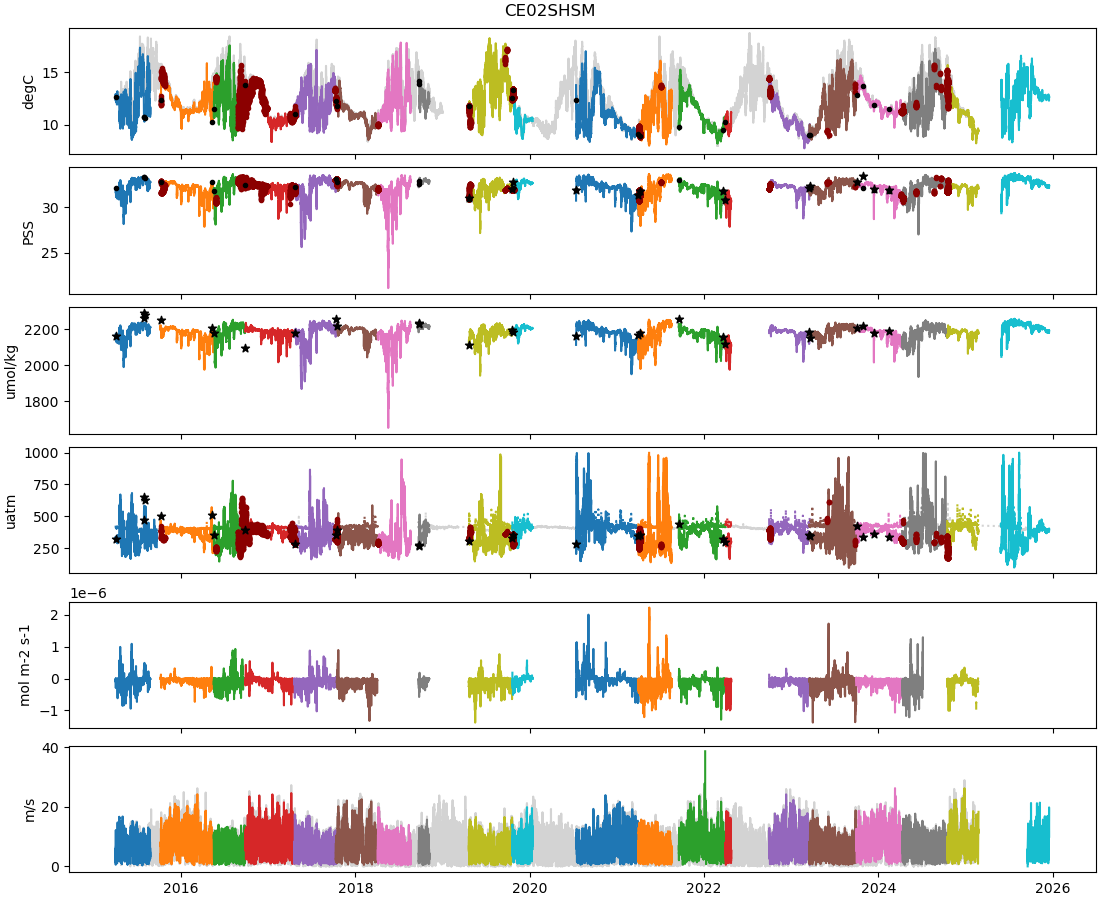

In [17]:
# select the moooring of interest
indx = 0  # CE02SHSM

# subselect the relevant discrete and SOCAT samples
samples = prep_samples(pco2[indx].copy(), discrete.copy(), 5.0)
external = prep_socat(pco2[indx].copy(), socat.copy(), sample_dist[indx])

# Plot the PCO2A data
fig1, axes1 = plt.subplots(nrows=6, ncols=1, sharex=True, figsize=(11, 9), constrained_layout=True)
fig1.canvas.header_visible = False
fig1.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4, ax5 = axes1.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = cycle(colors)  # set up an endless list of the standard colors for plotting

# add the NDBC data to the plot
ax0.plot(ndbc_46050['time'], ndbc_46050['wtmp'], label='46050', color='LightGrey')
ax5.plot(ndbc_46050['time'], ndbc_46050['normalized_10m_wind'], label='46050', color='LightGrey')

# add the air data from the offshore mooring 
ax3.plot(pco2[indx+1].time, pco2[indx+1].partial_pressure_co2_atm, ':', color='LightGrey', label='Air')

# plot the data per deployment (helps to see the overlaps)
grps = pco2[indx].groupby('deployment')
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    color = next(colors)
    ax0.plot(data.time, data.sea_surface_temperature, color=color, label='degC')
    ax1.plot(data.time, data.sea_surface_salinity, color=color, label='PSS')
    ax2.plot(data.time, data.alkalinity, color=color, label='Alk')
    ax3.plot(data.time, data.partial_pressure_co2_atm, ':', color=color, label='Air')
    ax3.plot(data.time, data.partial_pressure_co2_ssw, color=color, label='Water')
    ax4.plot(data.time, data.sea_to_air_co2_flux, color=color, label='flux')
    ax5.plot(data.time, data.normalized_10m_wind, color=color, label='Wind')    
    
# add the discrete sample data
ax0.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Calculated Alkalinity [umol/kg]'], marker='*', label='Discrete', color='Black', zorder=10)
ax3.scatter(samples['Start Time [UTC]'], samples['Discrete pCO2 [uatm]'], marker='*', label='Discrete', color='Black', zorder=10)

# add the SOCAT data
ax0.scatter(external['sample_date'], external['SST [deg.C]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax1.scatter(external['sample_date'], external['sal'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax3.scatter(external['sample_date'], external['pCO2 SSW [uatm]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)

# label the y-axes
ax0.set(ylabel='degC')
ax1.set(ylabel='PSS')
ax2.set(ylabel='umol/kg')
ax3.set(ylabel='uatm')
ax4.set(ylabel='mol m-2 s-1')
ax5.set(ylabel='m/s')

fig1.canvas.draw()
fig1.canvas.flush_events()
plt.show()
#display(fig1)

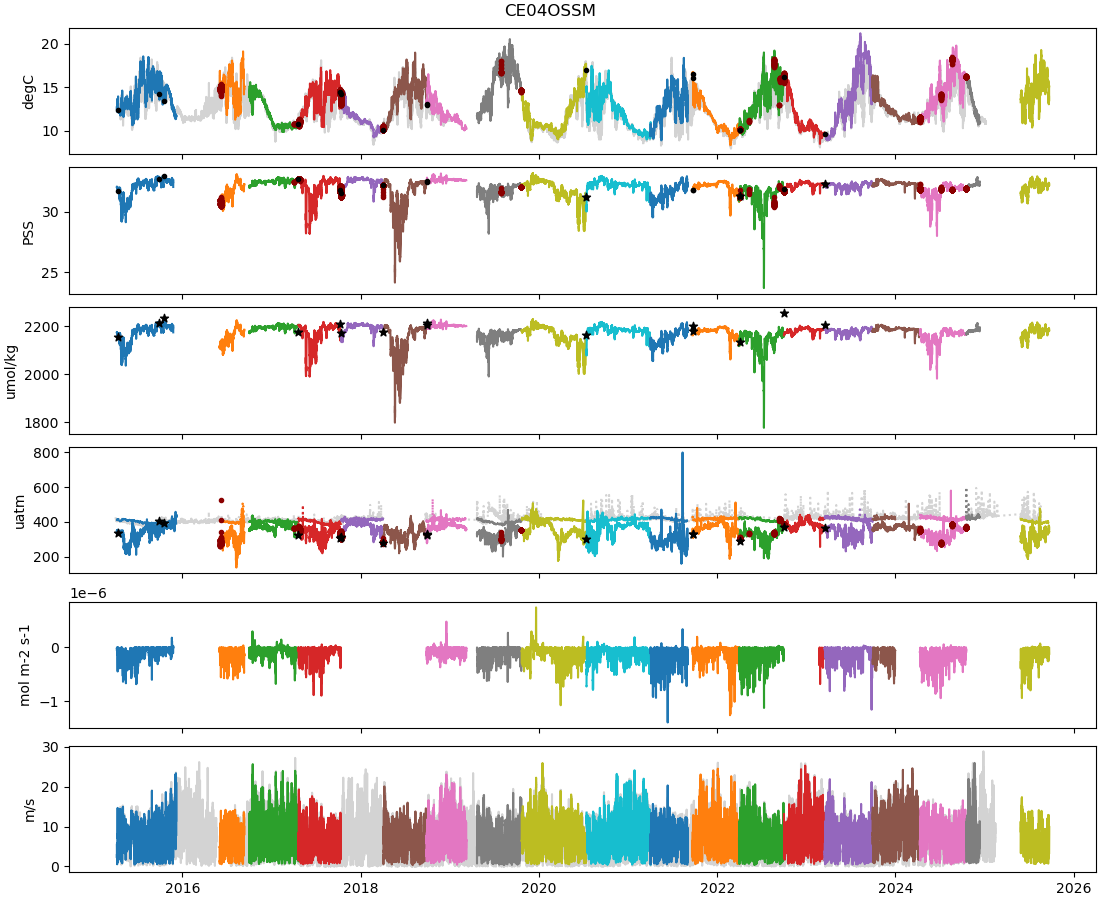

In [18]:
# select the moooring of interest
indx = 1  # CE04OSSM

# subselect the relevant discrete and SOCAT samples
samples = prep_samples(pco2[indx].copy(), discrete.copy(), sample_dist[indx])
external = prep_socat(pco2[indx].copy(), socat.copy(), sample_dist[indx])

# Plot the PCO2A data
fig2, axes2 = plt.subplots(nrows=6, ncols=1, sharex=True, figsize=(11, 9), constrained_layout=True)
fig2.canvas.header_visible = False
fig2.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4, ax5 = axes2.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = cycle(colors)  # set up an endless list of the standard colors for plotting

# add the NDBC data to the plot
ax0.plot(ndbc_46050['time'], ndbc_46050['wtmp'], label='46050', color='LightGrey')
ax5.plot(ndbc_46050['time'], ndbc_46050['normalized_10m_wind'], label='46050', color='LightGrey')

# add the air data from the shelf mooring 
ax3.plot(pco2[indx-1].time, pco2[indx-1].partial_pressure_co2_atm, ':', color='LightGrey', label='Air')

# plot the data per deployment (helps to see the overlaps)
grps = pco2[indx].groupby('deployment')
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    color = next(colors)
    ax0.plot(data.time, data.sea_surface_temperature, color=color, label='degC')
    ax1.plot(data.time, data.sea_surface_salinity, color=color, label='PSS')
    ax2.plot(data.time, data.alkalinity, color=color, label='Alk')
    ax3.plot(data.time, data.partial_pressure_co2_atm, ':', color=color, label='Air')
    ax3.plot(data.time, data.partial_pressure_co2_ssw, color=color, label='Water')
    ax4.plot(data.time, data.sea_to_air_co2_flux, color=color, label='flux')
    ax5.plot(data.time, data.normalized_10m_wind, color=color, label='Wind')    
    
# add the discrete sample data
ax0.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Calculated Alkalinity [umol/kg]'], marker='*', label='Discrete', color='Black', zorder=10)
ax3.scatter(samples['Start Time [UTC]'], samples['Discrete pCO2 [uatm]'], marker='*', label='Discrete', color='Black', zorder=10)

# add the SOCAT data
ax0.scatter(external['sample_date'], external['SST [deg.C]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax1.scatter(external['sample_date'], external['sal'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax3.scatter(external['sample_date'], external['pCO2 SSW [uatm]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)

# label the y-axes
ax0.set(ylabel='degC')
ax1.set(ylabel='PSS')
ax2.set(ylabel='umol/kg')
ax3.set(ylabel='uatm')
ax4.set(ylabel='mol m-2 s-1')
ax5.set(ylabel='m/s')

fig2.canvas.draw()
fig2.canvas.flush_events()
plt.show()
#display(fig2)

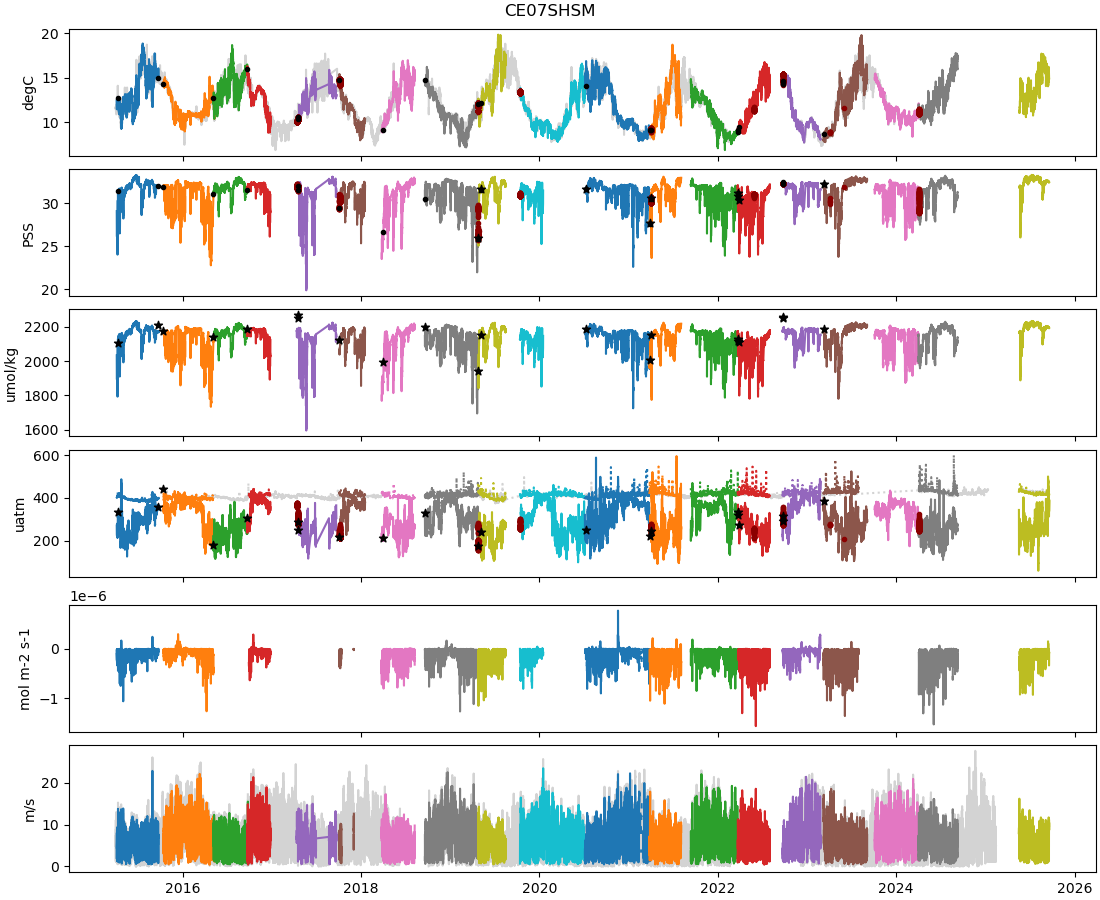

In [19]:
# select the moooring of interest
indx = 2  # CE07SHSM

# subselect the relevant discrete and SOCAT samples
samples = prep_samples(pco2[indx].copy(), discrete.copy(), sample_dist[indx])
external = prep_socat(pco2[indx].copy(), socat.copy(), sample_dist[indx])

# Plot the PCO2A data
fig3, axes3 = plt.subplots(nrows=6, ncols=1, sharex=True, figsize=(11, 9), constrained_layout=True)
fig3.canvas.header_visible = False
fig3.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4, ax5 = axes3.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = cycle(colors)  # set up an endless list of the standard colors for plotting

# add the NDBC data to the plot
ax0.plot(ndbc_46041['time'], ndbc_46041['wtmp'], label='46041', color='LightGrey')
ax5.plot(ndbc_46041['time'], ndbc_46041['normalized_10m_wind'], label='46041', color='LightGrey')

# add the air data from the offshore mooring 
ax3.plot(pco2[indx+1].time, pco2[indx+1].partial_pressure_co2_atm, ':', color='LightGrey', label='Air')

# plot the data per deployment (helps to see the overlaps)
grps = pco2[indx].groupby('deployment')
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    color = next(colors)
    ax0.plot(data.time, data.sea_surface_temperature, color=color, label='degC')
    ax1.plot(data.time, data.sea_surface_salinity, color=color, label='PSS')
    ax2.plot(data.time, data.alkalinity, color=color, label='Alk')
    ax3.plot(data.time, data.partial_pressure_co2_atm, ':', color=color, label='Air')
    ax3.plot(data.time, data.partial_pressure_co2_ssw, color=color, label='Water')
    ax4.plot(data.time, data.sea_to_air_co2_flux, color=color, label='flux')
    ax5.plot(data.time, data.normalized_10m_wind, color=color, label='Wind')    
    
# add the discrete sample data
ax0.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Calculated Alkalinity [umol/kg]'], marker='*', label='Discrete', color='Black', zorder=10)
ax3.scatter(samples['Start Time [UTC]'], samples['Discrete pCO2 [uatm]'], marker='*', label='Discrete', color='Black', zorder=10)

# add the SOCAT data
ax0.scatter(external['sample_date'], external['SST [deg.C]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax1.scatter(external['sample_date'], external['sal'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax3.scatter(external['sample_date'], external['pCO2 SSW [uatm]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)

# label the y-axes
ax0.set(ylabel='degC')
ax1.set(ylabel='PSS')
ax2.set(ylabel='umol/kg')
ax3.set(ylabel='uatm')
ax4.set(ylabel='mol m-2 s-1')
ax5.set(ylabel='m/s')

fig3.canvas.draw()
fig3.canvas.flush_events()
plt.show()
#display(fig3)

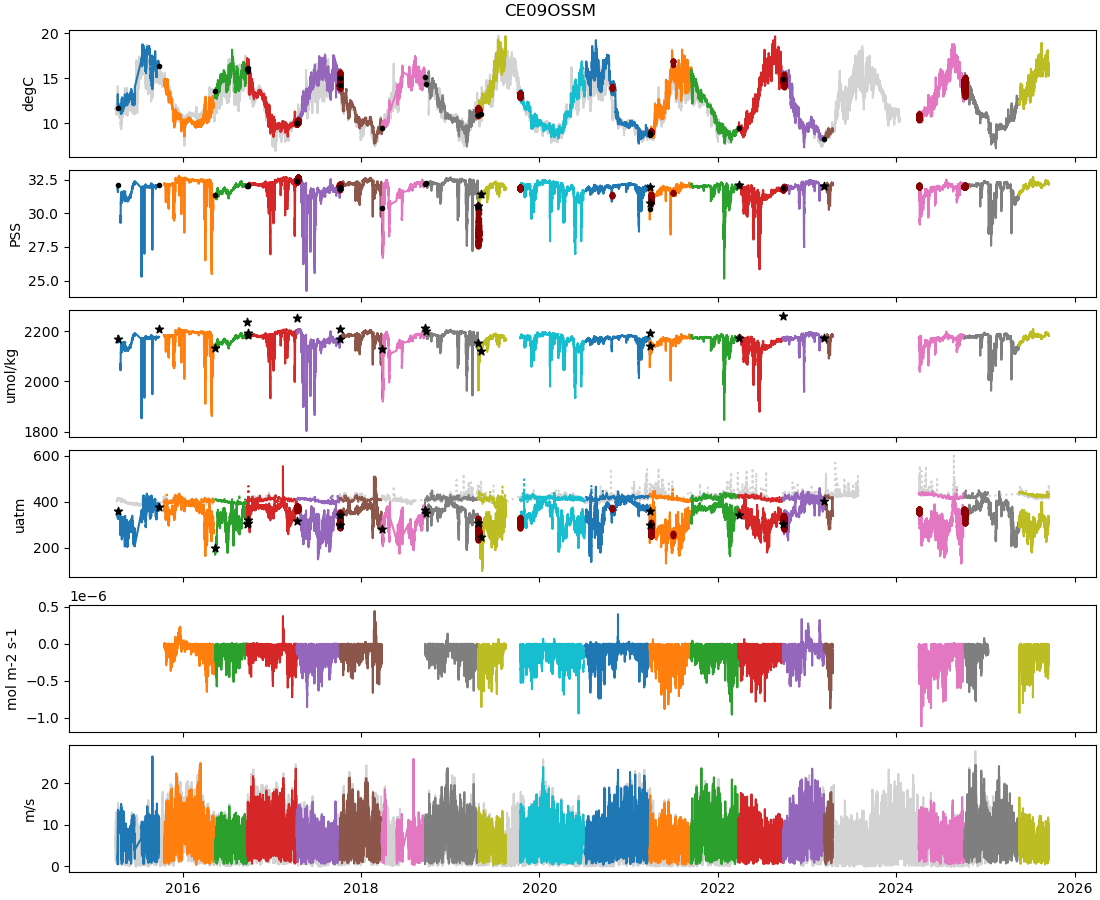

In [20]:
# select the moooring of interest
indx = 3  # CE09OSSM

# subselect the relevant discrete and SOCAT samples
samples = prep_samples(pco2[indx].copy(), discrete.copy(), sample_dist[indx])
external = prep_socat(pco2[indx].copy(), socat.copy(), sample_dist[indx])

# Plot the PCO2A data
fig4, axes4 = plt.subplots(nrows=6, ncols=1, sharex=True, figsize=(11, 9), constrained_layout=True)
fig4.canvas.header_visible = False
fig4.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4, ax5 = axes4.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = cycle(colors)  # set up an endless list of the standard colors for plotting

# add the NDBC data to the plot
ax0.plot(ndbc_46041['time'], ndbc_46041['wtmp'], label='46041', color='LightGrey')
ax5.plot(ndbc_46041['time'], ndbc_46041['normalized_10m_wind'], label='46041', color='LightGrey')

# add the air data from the shelf mooring 
ax3.plot(pco2[indx-1].time, pco2[indx-1].partial_pressure_co2_atm, ':', color='LightGrey', label='Air')

# plot the data per deployment (helps to see the overlaps)
grps = pco2[indx].groupby('deployment')
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    color = next(colors)
    ax0.plot(data.time, data.sea_surface_temperature, color=color, label='degC')
    ax1.plot(data.time, data.sea_surface_salinity, color=color, label='PSS')
    ax2.plot(data.time, data.alkalinity, color=color, label='Alk')
    ax3.plot(data.time, data.partial_pressure_co2_atm, ':', color=color, label='Air')
    ax3.plot(data.time, data.partial_pressure_co2_ssw, color=color, label='Water')
    ax4.plot(data.time, data.sea_to_air_co2_flux, color=color, label='flux')
    ax5.plot(data.time, data.normalized_10m_wind, color=color, label='Wind')    
    
# add the discrete sample data
ax0.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax1.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Calculated Alkalinity [umol/kg]'], marker='*', label='Discrete', color='Black', zorder=10)
ax3.scatter(samples['Start Time [UTC]'], samples['Discrete pCO2 [uatm]'], marker='*', label='Discrete', color='Black', zorder=10)

# add the SOCAT data
ax0.scatter(external['sample_date'], external['SST [deg.C]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax1.scatter(external['sample_date'], external['sal'], marker='.', label='SOCAT', color='DarkRed', zorder=9)
ax3.scatter(external['sample_date'], external['pCO2 SSW [uatm]'], marker='.', label='SOCAT', color='DarkRed', zorder=9)

# label the y-axes
ax0.set(ylabel='degC')
ax1.set(ylabel='PSS')
ax2.set(ylabel='umol/kg')
ax3.set(ylabel='uatm')
ax4.set(ylabel='mol m-2 s-1')
ax5.set(ylabel='m/s')

fig4.canvas.draw()
fig4.canvas.flush_events()
plt.show()
#display(fig4)

## Continuous Timeseries (and Zarr ZipStore)

Convert the data to continuous timeseries, merging overlapping deployment data, and create both NetCDF and Zarr ZipStore files of the continuous records.

In [21]:
%%time
# reset the data to continuous records (no overlapping deployments) and save the results to both NetCDF and a Zarr ZipStore
sites = ['CE02SHSM', 'CE04OSSM', 'CE07SHSM', 'CE09OSSM']
node = 'SBD12'
sensor = '04-PCO2AA000'
for i, site in enumerate(sites):
    # create a continuous, monotonic time record (no deployment overlaps)
    data = pco2[i].copy()
    remove = ['longitude', 'latitude', 'depth', 'station_name']
    data = data.drop_vars(remove)
    data = data.groupby('time').mean(skipna=True)
    data = metadata_reset(data, site, node, sensor, [1.25, 1.25, 1.25], PCO2A)
    data = data.drop_vars('deployment')
    
    # save the continuous data for future analysis
    #nc_file = os.path.join(pco2a_path, '-'.join([site, node, sensor]) + '.hourly.continuous.nc')
    #data.to_netcdf(nc_file, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)

    # Create a Zarr ZipStore
    #zip_file = os.path.join(pco2a_path, '-'.join([site, node, sensor]) + '.hourly.continuous.zarr.zip')
    #with zarr.storage.ZipStore(zip_file, mode="w") as store:
    #    # Write the Xarray Dataset to the ZipStore
    #    data.to_zarr(store=store, encoding=ENCODINGS)

    pco2[i] = data.copy()

CPU times: user 2.69 s, sys: 190 ms, total: 2.88 s
Wall time: 10 s


## Cross-Comparisons: Discrete and SOCAT

Plot the discrete sample and SOCAT against the mooring data to assess the overall data quality (relationships should be 1:1).

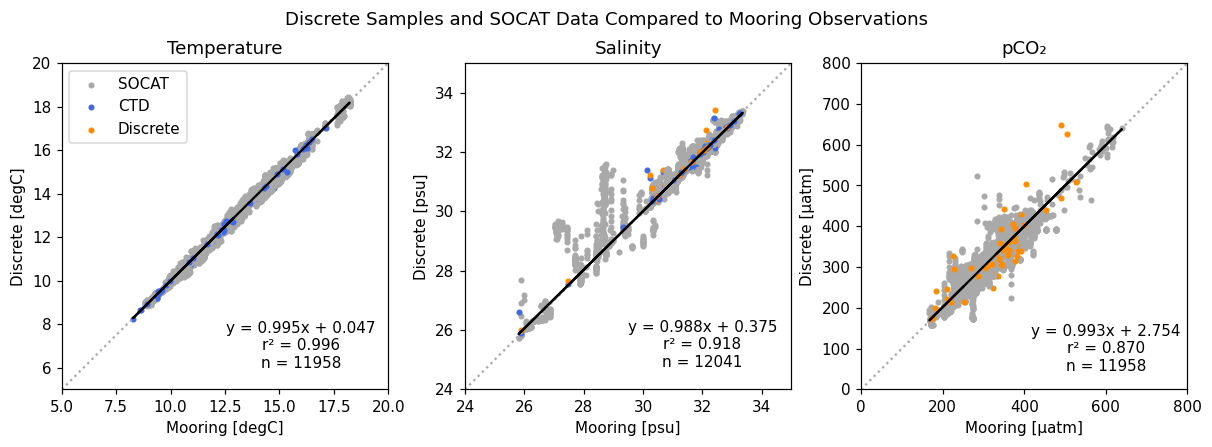

In [22]:
fig5, axes5 = plt.subplots(nrows=1, ncols=3, squeeze=True, figsize=(11, 4), constrained_layout=True)
fig5.canvas.header_visible = False
fig5.suptitle('Discrete Samples and SOCAT Data Compared to Mooring Observations')

# create the 1:1 lines
axes5[0].plot(np.arange(5, 21), np.arange(5, 21), ':', color='DarkGrey')
axes5[1].plot(np.arange(24, 36), np.arange(24, 36), ':', color='DarkGrey')
axes5[2].plot(np.arange(0, 801), np.arange(0, 801), ':', color='DarkGrey')

# list to hold the discrete sample data
full_discrete = []
full_socat = []
for i, data in enumerate(pco2):
    # locate the discrete samples that correspond to the mooring
    samples = prep_samples(data.copy(), discrete, dist=sample_dist[i])
    full_discrete.append(samples)  # append to the list for later stats

    # locate the SOCAT data thot correspond to the mooring
    external = prep_socat(data, socat, dist=sample_dist[i])
    full_socat.append(external)
    
    # plot the temperature, salinity, alkalinity and pCO2
    axes5[0].scatter(external['sea_surface_temperature'], external['SST [deg.C]'], marker='.', label='SOCAT', color='DarkGrey')
    axes5[0].scatter(samples['sea_surface_temperature'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='RoyalBlue')
    
    axes5[1].scatter(external['sea_surface_salinity'], external['sal'], marker='.', label='SOCAT', color='DarkGrey')
    axes5[1].scatter(samples['sea_surface_salinity'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='RoyalBlue')
    axes5[1].scatter(samples['sea_surface_salinity'], samples['Discrete Salinity [psu]'], marker='.', label='Discrete', color='DarkOrange')
    
    axes5[2].scatter(external['pco2_ssw'], external['pCO2 SSW [uatm]'], marker='.', label='SOCAT', color='DarkGrey')
    axes5[2].scatter(samples['pco2_ssw'], samples['Discrete pCO2 [uatm]'], marker='.', label='Discrete', color='DarkOrange')

# convert the list of samples to a pandas dataframe
full = pd.concat(full_discrete, ignore_index=True)
external = pd.concat(full_socat, ignore_index=True)

# temperature regression and plot finalizing
handles, labels = axes5[1].get_legend_handles_labels()
axes5[0].legend(handles[:3], labels[:3])

axes5[0].set(aspect='equal', xlim=[5, 20], ylim=[5, 20], title='Temperature', xlabel='Mooring [degC]', ylabel='Discrete [degC]')
x = np.concat((full['sea_surface_temperature'].values, external['sea_surface_temperature'].values))
y = np.concat((full[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1, skipna=True).values, external['SST [deg.C]'].values))
mask = np.isnan(x) & np.isnan(y)
m, b, r_sqrd = robust_regression(x, y)
y_fit = m * x + b
axes5[0].plot(x, y_fit, '-', color='Black')
axes5[0].text(16, 7, f'y = {m:.3f}x + {b:.3f}\nr\u00b2 = {r_sqrd:.3f}\nn = {sum(~mask)}', horizontalalignment='center', verticalalignment='center');

axes5[1].set(aspect='equal', xlim=[24, 35], ylim=[24, 35], title='Salinity', xlabel='Mooring [psu]', ylabel='Discrete [psu]')
x = np.concat((full['sea_surface_salinity'].values, full['sea_surface_salinity'].values, external['sea_surface_salinity'].values))
y = np.concat((full[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1, skipna=True).values, full['Discrete Salinity [psu]'].values, external['sal'].values))
mask = np.isnan(x) & np.isnan(y)
m, b, r_sqrd = robust_regression(x, y)
y_fit = m * x + b
axes5[1].plot(x, y_fit, '-', color='Black')
axes5[1].text(32, 25.5, f'y = {m:.3f}x + {b:.3f}\nr\u00b2 = {r_sqrd:.3f}\nn = {sum(~mask)}', horizontalalignment='center', verticalalignment='center');

axes5[2].set(aspect='equal', xlim=[0, 800], ylim=[0, 800], title='pCO\u2082', xlabel='Mooring [\u03BCatm]', ylabel='Discrete [\u03BCatm]')
x = np.concat((full['pco2_ssw'].values, external['pco2_ssw'].values))
y = np.concat((full['Discrete pCO2 [uatm]'].values, external['pCO2 SSW [uatm]'].values))
mask = np.isnan(x) & np.isnan(y)
m, b, r_sqrd = robust_regression(x, y)
y_fit = m * x + b
axes5[2].plot(x, y_fit, '-', color='Black')
axes5[2].text(600, 100, f'y = {m:.3f}x + {b:.3f}\nr\u00b2 = {r_sqrd:.3f}\nn = {sum(~mask)}', horizontalalignment='center', verticalalignment='center');

display(fig5)